In [2]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("indiv_spearman_duplicates_grouped_norepeat_RfxCas13a_validation_cnn2.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q3 < 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("indiv_features_with_negative_IQR_RfxCas13a_validation_cnn2.csv", index=False)


                 Feature     Q1     Q3  Median Spearman Correlation
0          Pos1_Unpaired -0.327 -0.325                       -0.325
1          Pos2_Unpaired -0.370 -0.370                       -0.370
2          Pos3_Unpaired -0.375 -0.126                       -0.348
3          Pos4_Unpaired -0.399 -0.300                       -0.367
4          Pos5_Unpaired -0.412 -0.059                       -0.296
..                   ...    ...    ...                          ...
62  Pos61_Paired-Closing -0.691 -0.482                       -0.588
63  Pos62_Paired-Closing -0.596 -0.216                       -0.328
64  Pos64_Paired-Closing -0.671 -0.569                       -0.598
65  Pos65_Paired-Closing -0.638 -0.545                       -0.600
66  Pos66_Paired-Closing -0.513 -0.009                       -0.178

[67 rows x 4 columns]


/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_47227/2195017825.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


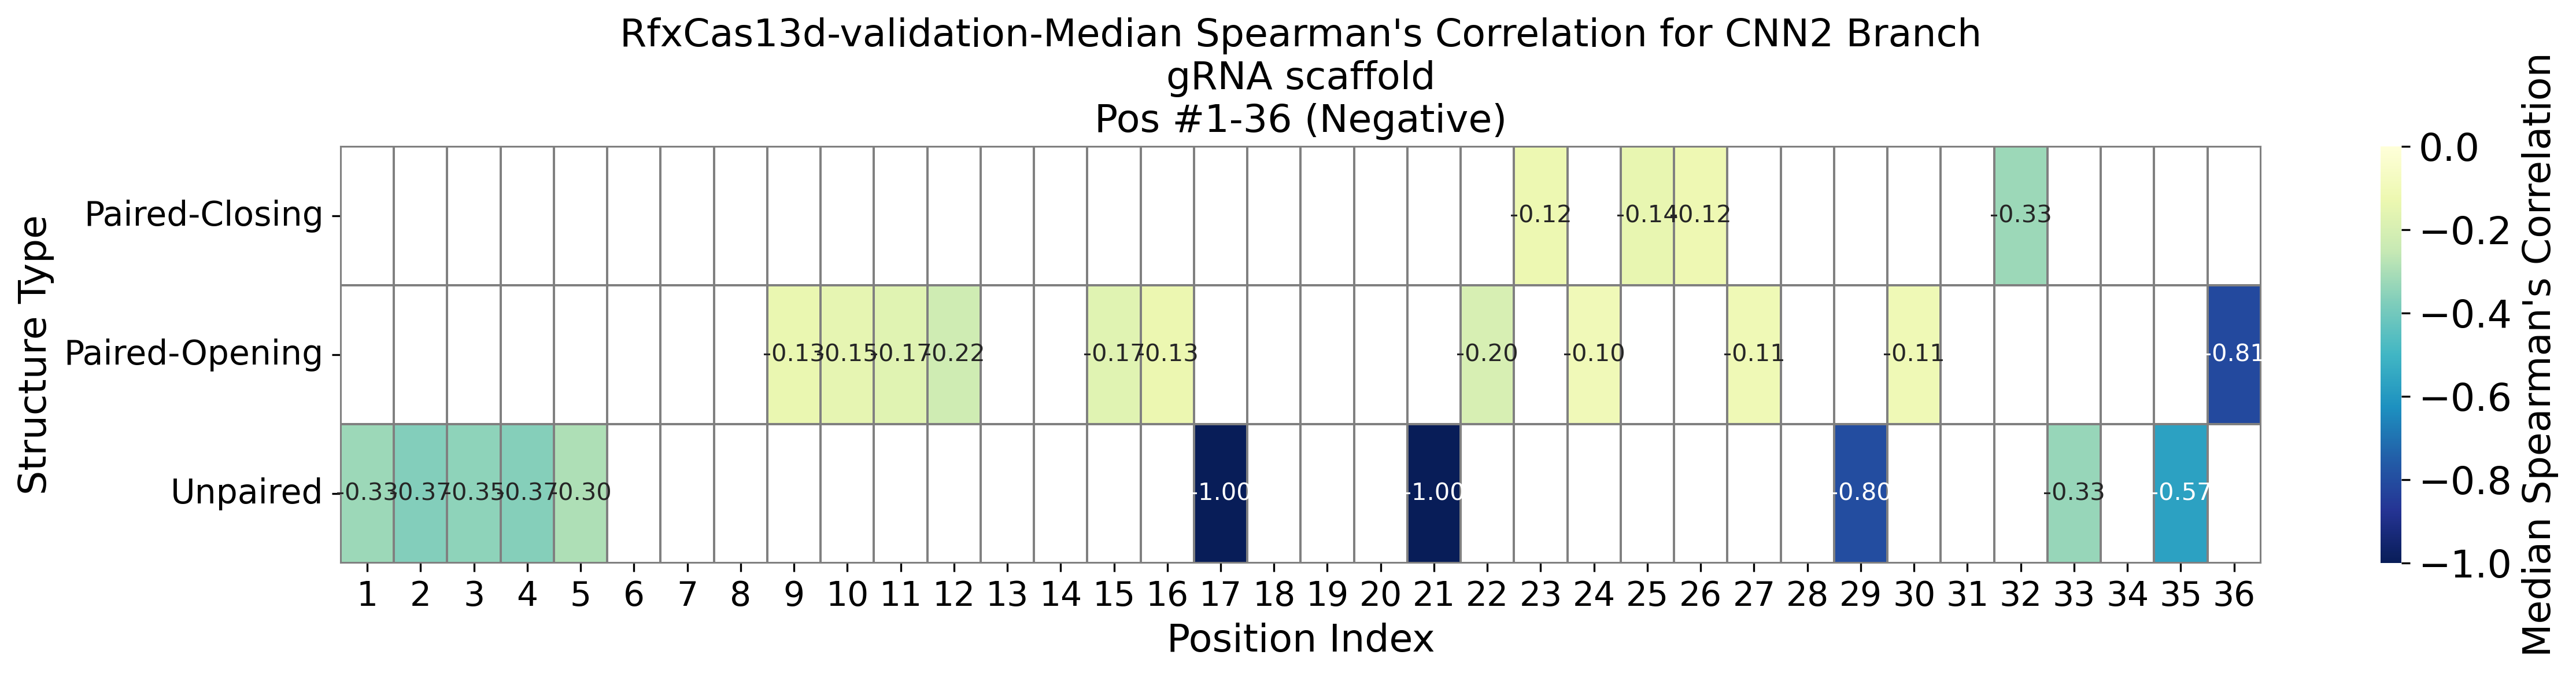

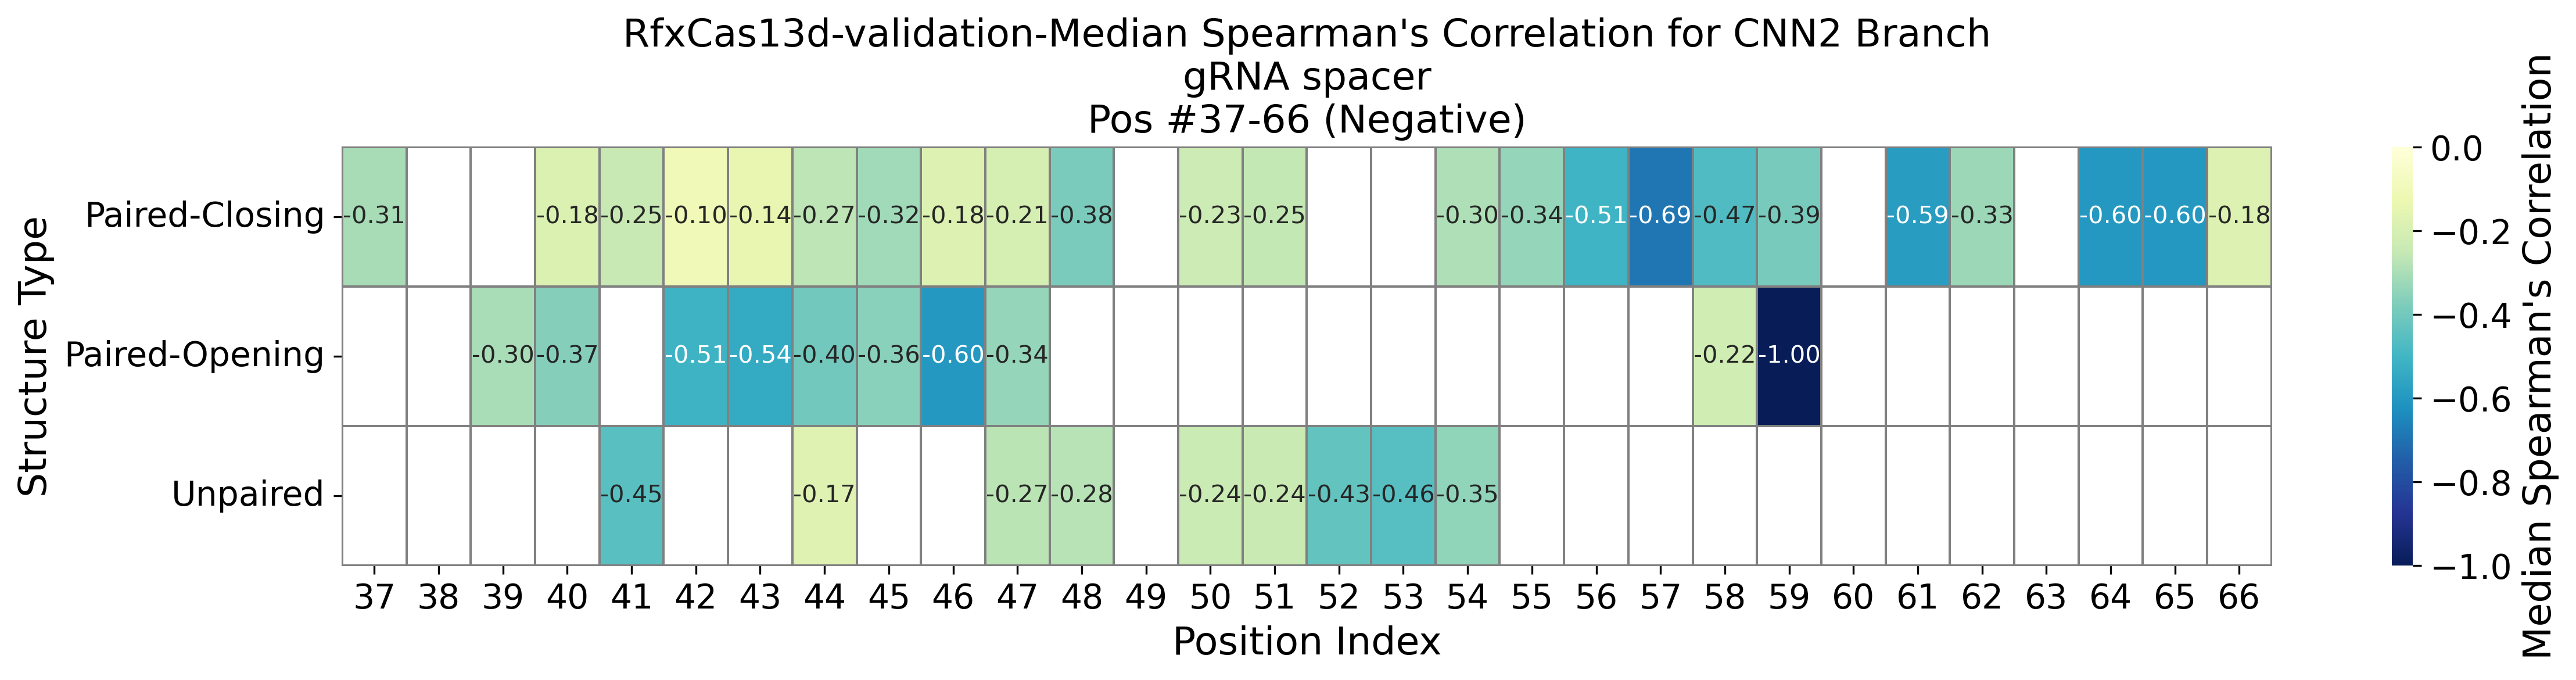

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Load processed feature list ===
iqr_df = pd.read_csv("indiv_features_with_negative_IQR_RfxCas13a_validation_cnn2.csv")

# === Extract Pos and Base Type (here Base = sub-feature like Paired, Opening, etc.) ===
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(.+)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# === Handle duplicate (Base, Pos) entries by averaging ===
iqr_df_grouped = iqr_df.groupby(['Base', 'Pos'])["Median Spearman Correlation"].mean().reset_index()

# === Pivot to heatmap format ===
heatmap_data = iqr_df_grouped.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Optional: Set fixed row order
row_order = sorted(heatmap_data.index.unique())
heatmap_data = heatmap_data.reindex(row_order)

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(1, 67)  # 1 to 67 inclusive
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

# Create mask for missing values
mask = heatmap_data.isna()

# === Create two heatmap panels ===

# Heatmap for positions 1–36
fig1, ax1 = plt.subplots(figsize=(16, 4), dpi=300)
hm1 = sns.heatmap(
    heatmap_data.loc[:, 1:36],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu_r",
    vmin=-1,
    vmax=0,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 1:36].isna(),
    ax=ax1
)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax1.set_xlabel("Position Index", fontsize=16)
ax1.set_ylabel("Structure Type", fontsize=16)
ax1.set_title(
    "RfxCas13d-validation-Median Spearman's Correlation for CNN2 Branch\n"
    'gRNA scaffold\n'
    "Pos #1-36 (Negative)",
    fontsize=16
)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar1 = hm1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=16)
cbar1.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()

# Heatmap for positions 37-66
fig2, ax2 = plt.subplots(figsize=(16, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 37:66],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu_r",
    vmin=-1,
    vmax=0,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 37:66].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "RfxCas13d-validation-Median Spearman's Correlation for CNN2 Branch\n"
    'gRNA spacer\n'
    "Pos #37-66 (Negative)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()

